## ******** Naive Bayes ********

Naive Bayes is a fast, simple, and highly effective classification algorithm based on Bayes’ Theorem. It assumes that features are conditionally independent given the class, which makes computation easy but “naive.” It is widely used in spam filtering, sentiment analysis, text classification, and medical diagnosis.

#### Key Points of Naive Bayes
Type of Algorithm: Probabilistic, supervised learning classifier.

Core Idea: Uses Bayes’ theorem to calculate the probability of a class given features.
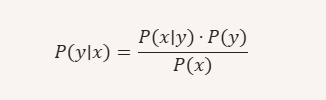

### Variants:
* GaussianNB → for continuous features (assumes normal distribution).
* MultinomialNB → for text classification, word counts, frequencies.
* BernoulliNB → for binary features (e.g., word presence/absence).
* CategoricalNB → for categorical variables.

#### Advantages:
* Very fast and efficient on large datasets.
* Works well with high-dimensional data (like text).
* Requires small training data.

Example (Spam Classification)
Imagine classifying emails as spam or ham:

Prior: 𝑃(𝑠𝑝𝑎𝑚)=0.4, 𝑃(ℎ𝑎𝑚)=0.6.

Likelihood: Words like “free” and “offer” are more frequent in spam.

Posterior: If an email contains “free offer,” Naive Bayes multiplies probabilities and predicts spam.

# Implementation of Naive Bayes

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Libraries Import Sucessfully ")

Libraries Import Sucessfully 


In [2]:
df=pd.read_csv('Titanic_preprocessed_data.csv')
df.head()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,0,3,1,22,1,0,7,2,0
1,1,1,1,0,38,1,0,71,0,0
2,2,1,3,0,26,0,0,7,2,1
3,3,1,1,0,35,1,0,53,2,0
4,4,0,3,1,35,0,0,8,2,1


In [3]:
X=df.drop("survived",axis=1)
y=df['survived']

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
# import the naive Bayes from Sklearn 
from sklearn.naive_bayes import GaussianNB

In [6]:
model_NB=GaussianNB()

In [7]:
model_NB.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[440.,271.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.62,0.38]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,6.577e-05
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Unnamed: 0','pclass','sex',...,'fare','embarked','alone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 9)","[[441.98, 2.54, 0.86,..., 22.12, 1.65, 0.67], [452.32, 1.97, 0.34,..., 47.09, 1.36, 0.49]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 9)","[[67590.31, 0.54, 0.12,..., 1074.12, 0.49, 0.22], [62745.55, 0.74, 0.23,..., 4213.26, 0.78, 0.25]]"


In [12]:
y_pred_NB=model_NB.predict(X_test)
y_pred_NB

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1], dtype=int64)

In [13]:
y_test

280    0
434    1
39     1
417    0
584    1
      ..
432    0
806    0
25     1
84     1
10     1
Name: survived, Length: 178, dtype: int64

In [14]:
from sklearn.metrics import  accuracy_score , confusion_matrix , classification_report

In [15]:
accuracy_score(y_test,y_pred_NB)

0.7696629213483146

In [16]:
confusion_matrix(y_test,y_pred_NB)

array([[84, 25],
       [16, 53]], dtype=int64)

In [17]:
print(classification_report(y_test,y_pred_NB))

              precision    recall  f1-score   support

           0       0.84      0.77      0.80       109
           1       0.68      0.77      0.72        69

    accuracy                           0.77       178
   macro avg       0.76      0.77      0.76       178
weighted avg       0.78      0.77      0.77       178

